# 01 _ Data Exploration

## Download & Parse

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)
DATASET_FILE = DATA_DIR / "dataset.txt"
CSV_FILE = DATA_DIR / "df.csv"

In [2]:
if not DATASET_FILE.exists():
    print("Downloading dataset from OpenML...")
    r = requests.get("https://www.openml.org/data/download/22102255/dataset", allow_redirects=True)
    DATASET_FILE.write_bytes(r.content)
    print(f"Downloaded {len(r.content):,} bytes")
else:
    print(f"Using cached dataset ({DATASET_FILE.stat().st_size:,} bytes)")

Using cached dataset (50,294,086 bytes)


In [4]:
# ARFF format into df
columns = []
rows = []

for line in DATASET_FILE.read_text().splitlines():
    line = line.strip()
    if line.startswith("@ATTRIBUTE"):
        columns.append(line.split(" ")[1])
    elif not line.startswith("@") and not line.startswith("%") and line:
        rows.append(line)

# wright to csv
CSV_FILE.write_text(",".join(columns) + "\n" + "\n".join(rows))

df = pd.read_csv(CSV_FILE)
df.columns = columns

# target: 1 = T wins, 0 = CT wins
df["t_win"] = df.round_winner.astype("category").cat.codes

print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(columns)}")
df.head()

Dataset shape: (122410, 98)
Columns: 97


,time_left,ct_score,t_score,map,bomb_planted,ct_health,t_health,ct_armor,t_armor,ct_money,...,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,round_winner,t_win
0,175.00,0.0,0.0,de_dust2,False,500.0,500.0,0.0,0.0,4000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT,0
1,156.03,0.0,0.0,de_dust2,False,500.0,500.0,400.0,300.0,600.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,CT,0
2,96.03,0.0,0.0,de_dust2,False,391.0,400.0,294.0,200.0,750.0,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,CT,0
3,76.03,0.0,0.0,de_dust2,False,391.0,400.0,294.0,200.0,750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT,0
4,174.97,1.0,0.0,de_dust2,False,500.0,500.0,192.0,0.0,18350.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CT,0


## Stats

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122410 entries, 0 to 122409
Data columns (total 98 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   time_left                     122410 non-null  float64
 1   ct_score                      122410 non-null  float64
 2   t_score                       122410 non-null  float64
 3   map                           122410 non-null  str    
 4   bomb_planted                  122410 non-null  bool   
 5   ct_health                     122410 non-null  float64
 6   t_health                      122410 non-null  float64
 7   ct_armor                      122410 non-null  float64
 8   t_armor                       122410 non-null  float64
 9   ct_money                      122410 non-null  float64
 10  t_money                       122410 non-null  float64
 11  ct_helmets                    122410 non-null  float64
 12  t_helmets                     122410 non-null  float64


In [6]:
df.describe()

,time_left,ct_score,t_score,ct_health,t_health,ct_armor,t_armor,ct_money,t_money,ct_helmets,...,t_grenade_flashbang,ct_grenade_smokegrenade,t_grenade_smokegrenade,ct_grenade_incendiarygrenade,t_grenade_incendiarygrenade,ct_grenade_molotovgrenade,t_grenade_molotovgrenade,ct_grenade_decoygrenade,t_grenade_decoygrenade,t_win
count,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,...,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000,122410.000000
mean,97.886922,6.709239,6.780435,412.106568,402.714500,314.142121,298.444670,9789.023773,11241.036680,2.053901,...,1.858100,1.540814,1.627146,1.001969,0.019819,0.048011,1.352095,0.027694,0.025750,0.509811
std,54.465238,4.790362,4.823543,132.293290,139.919033,171.029736,174.576545,11215.042286,12162.806759,1.841470,...,1.794473,1.737804,1.829147,1.458084,0.143933,0.227669,1.663246,0.169531,0.164162,0.499906
min,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,54.920000,3.000000,3.000000,350.000000,322.000000,194.000000,174.000000,1300.000000,1550.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,94.910000,6.000000,6.000000,500.000000,500.000000,377.000000,334.000000,5500.000000,7150.000000,2.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,166.917500,10.000000,10.000000,500.000000,500.000000,486.000000,468.000000,14600.000000,18000.000000,4.000000,...,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000
max,175.000000,32.000000,33.000000,500.000000,600.000000,500.000000,500.000000,80000.000000,80000.000000,5.000000,...,7.000000,6.000000,9.000000,5.000000,3.000000,3.000000,5.000000,3.000000,2.000000,1.000000


In [7]:
# balance
counts = df["t_win"].value_counts()
print(f"CT wins: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"T wins:  {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")

CT wins: 60,004 (49.0%)
T wins:  62,406 (51.0%)


## Feature Correlations

In [ ]:
# correlation with target
corr = df.corr(numeric_only=True)["t_win"].drop("t_win").sort_values(key=abs, ascending=False)
print("Top 25 features by |correlation| with t_win:\n")
print(corr.head(25).to_string())

Top 25 features by |correlation| with t_win:

ct_armor                       -0.336382
ct_helmets                     -0.308255
t_helmets                       0.297458
ct_defuse_kits                 -0.291557
t_armor                         0.290753
ct_grenade_flashbang           -0.253868
ct_players_alive               -0.216798
ct_grenade_smokegrenade        -0.209975
ct_weapon_awp                  -0.198626
t_weapon_ak47                   0.194147
ct_health                      -0.190662
bomb_planted                    0.187101
ct_weapon_m4a4                 -0.178008
ct_grenade_hegrenade           -0.168781
ct_grenade_incendiarygrenade   -0.168517
ct_weapon_ak47                 -0.166855
t_grenade_flashbang             0.166839
ct_weapon_sg553                -0.163963
t_weapon_sg553                  0.163709
ct_weapon_usps                 -0.152893
t_weapon_awp                    0.149878
t_players_alive                 0.142518
t_grenade_smokegrenade          0.140348
t_weapon_us

In [38]:
# select features with |correlation| > 0.15
selected = corr[corr.abs() > 0.15].index.tolist()
print(f"Selected {len(selected)} features with |corr| > 0.15:\n")
for f in selected:
    print(f"  {f}: {corr[f]:.4f}")

Selected 20 features with |corr| > 0.15:

  ct_armor: -0.3364
  ct_helmets: -0.3083
  t_helmets: 0.2975
  ct_defuse_kits: -0.2916
  t_armor: 0.2908
  ct_grenade_flashbang: -0.2539
  ct_players_alive: -0.2168
  ct_grenade_smokegrenade: -0.2100
  ct_weapon_awp: -0.1986
  t_weapon_ak47: 0.1941
  ct_health: -0.1907
  bomb_planted: 0.1871
  ct_weapon_m4a4: -0.1780
  ct_grenade_hegrenade: -0.1688
  ct_grenade_incendiarygrenade: -0.1685
  ct_weapon_ak47: -0.1669
  t_grenade_flashbang: 0.1668
  ct_weapon_sg553: -0.1640
  t_weapon_sg553: 0.1637
  ct_weapon_usps: -0.1529


## Visualizations

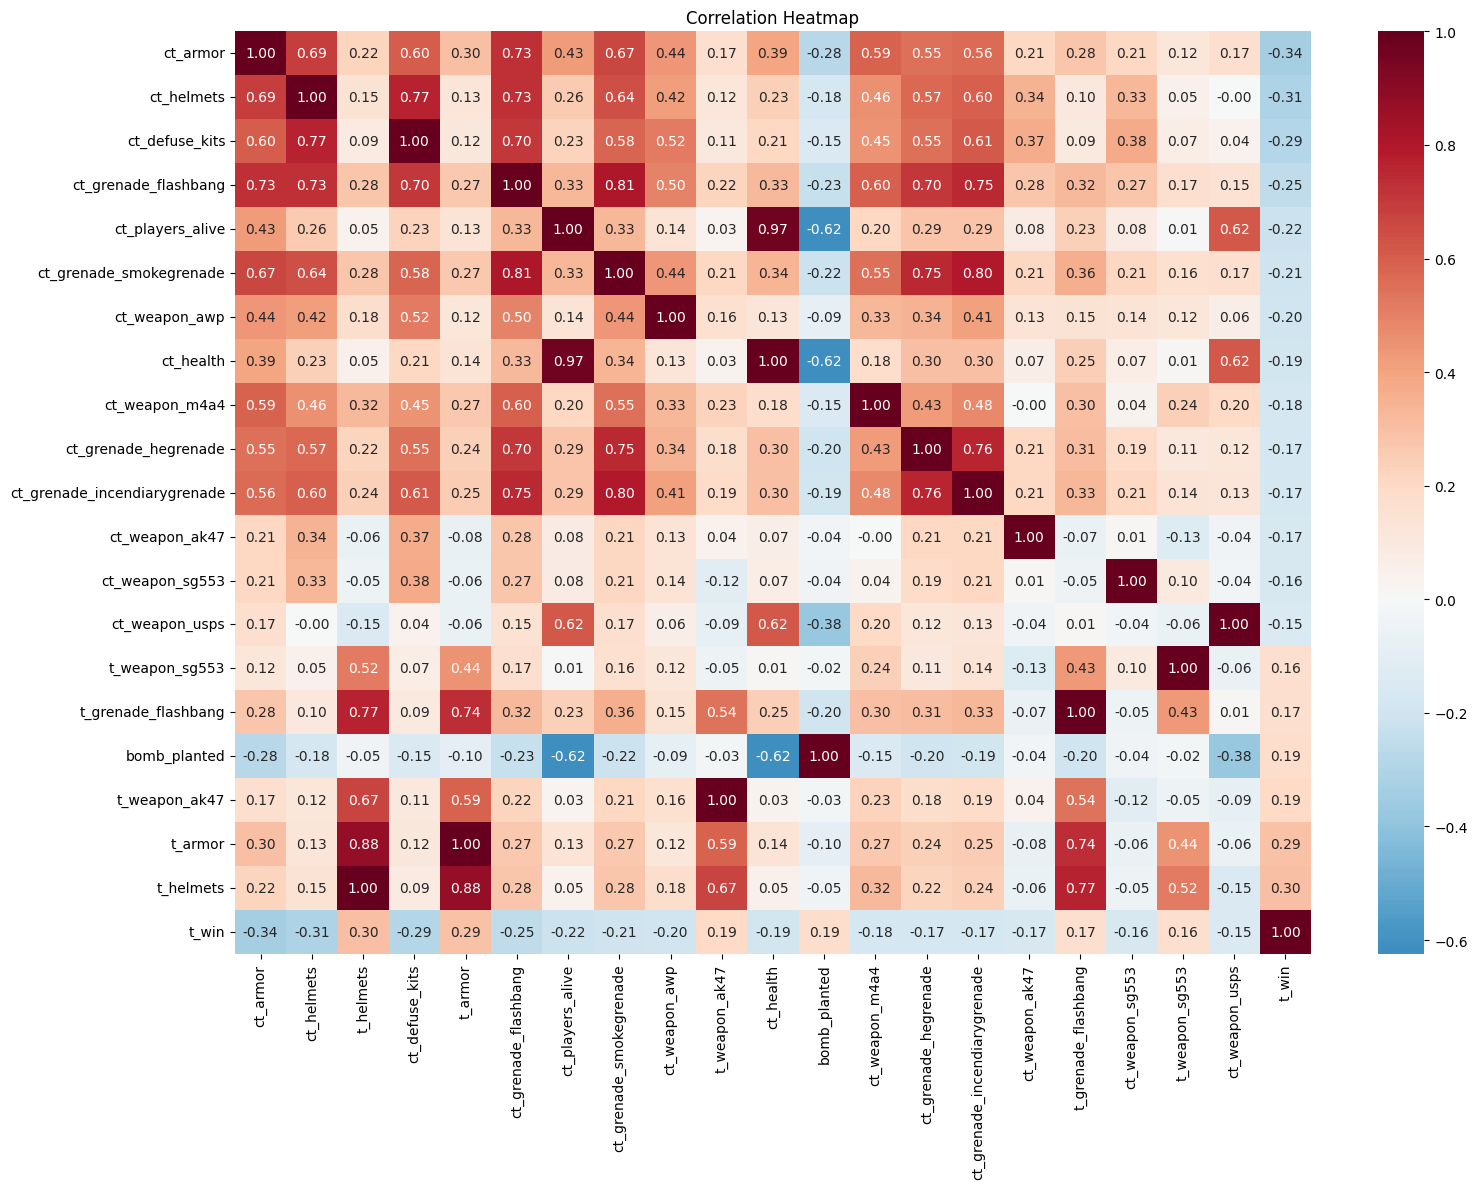

In [22]:
df_sel = df[selected + ["t_win"]]

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(df_sel.corr(numeric_only=True).sort_values(by="t_win"), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

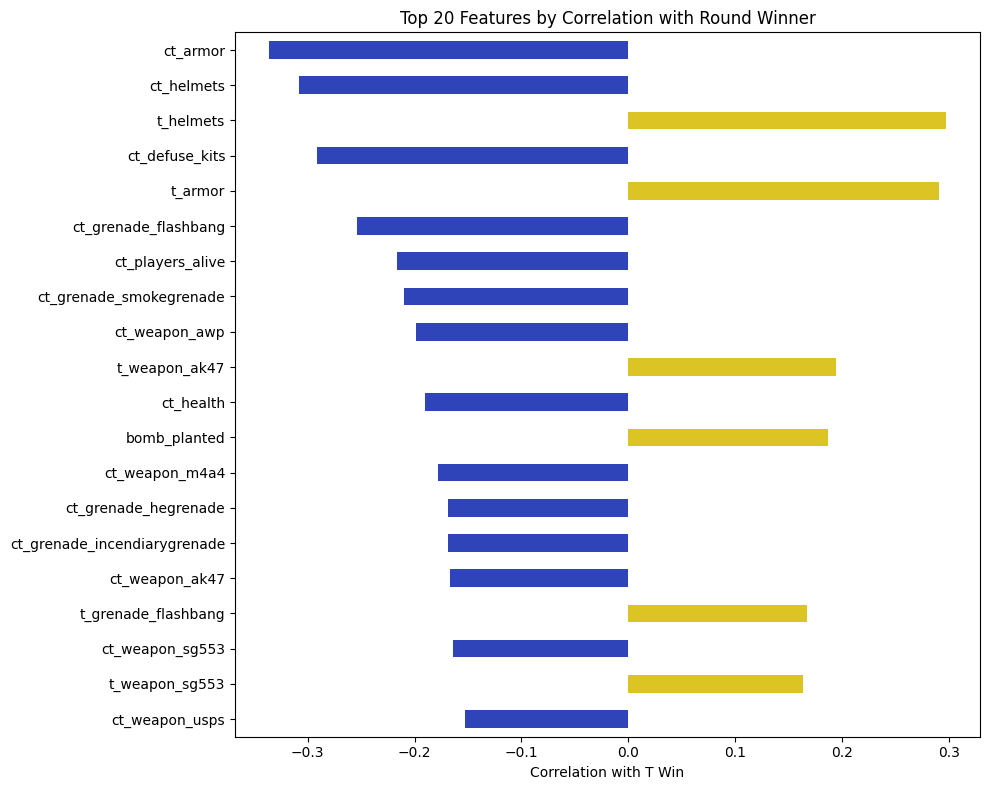

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2f44b9" if v < 0 else "#ddc425" for v in corr.head(20).values]
corr.head(20).plot.barh(ax=ax, color=colors)
ax.set_xlabel("Correlation with T Win")
ax.set_title("Top 20 Features by Correlation with Round Winner")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

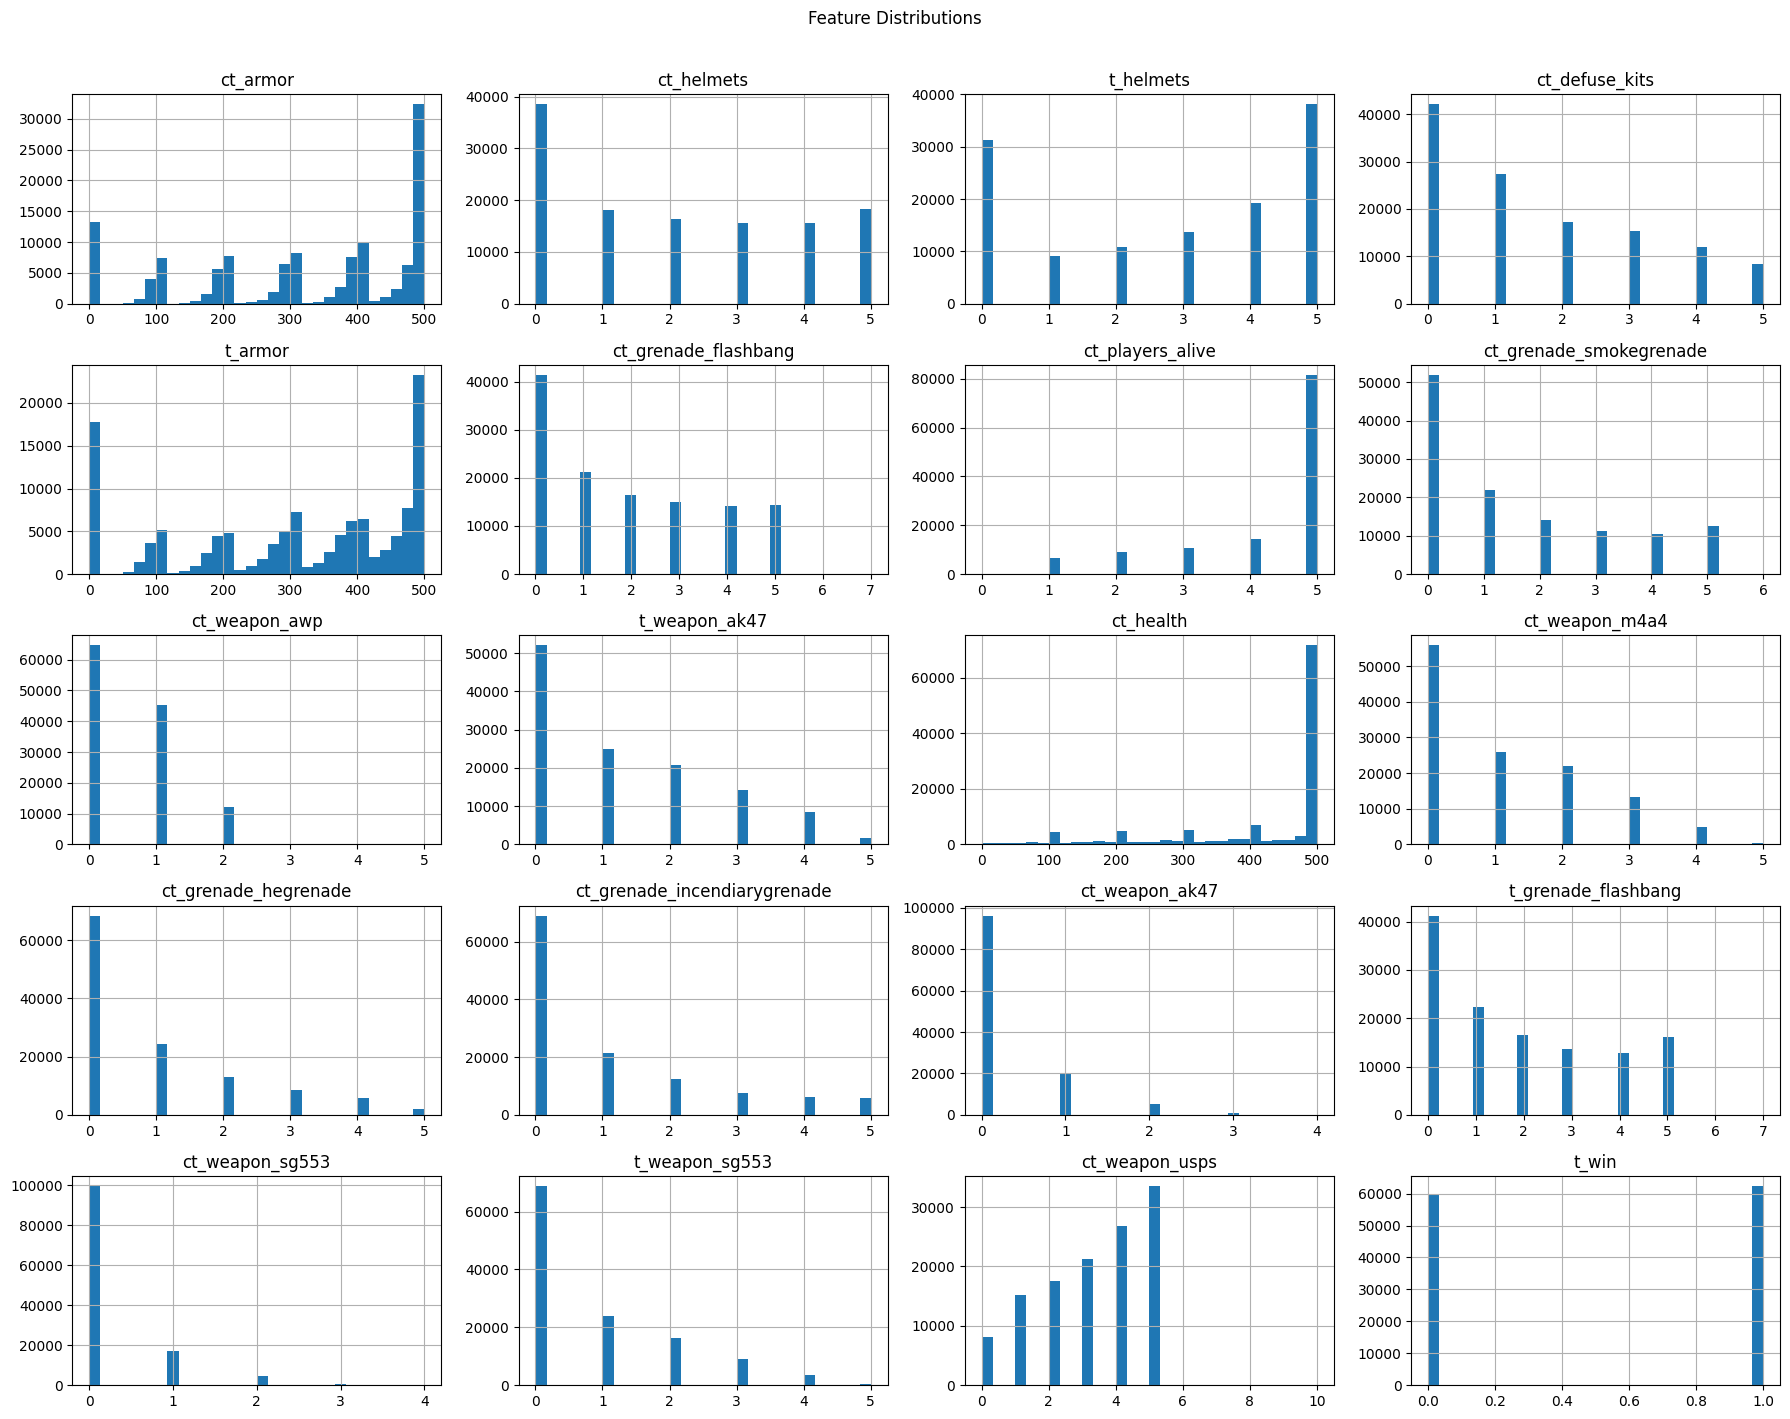

In [24]:
df_sel.hist(figsize=(18, 14), bins=30)
plt.suptitle("Feature Distributions", y=1.01)
plt.tight_layout()
plt.show()

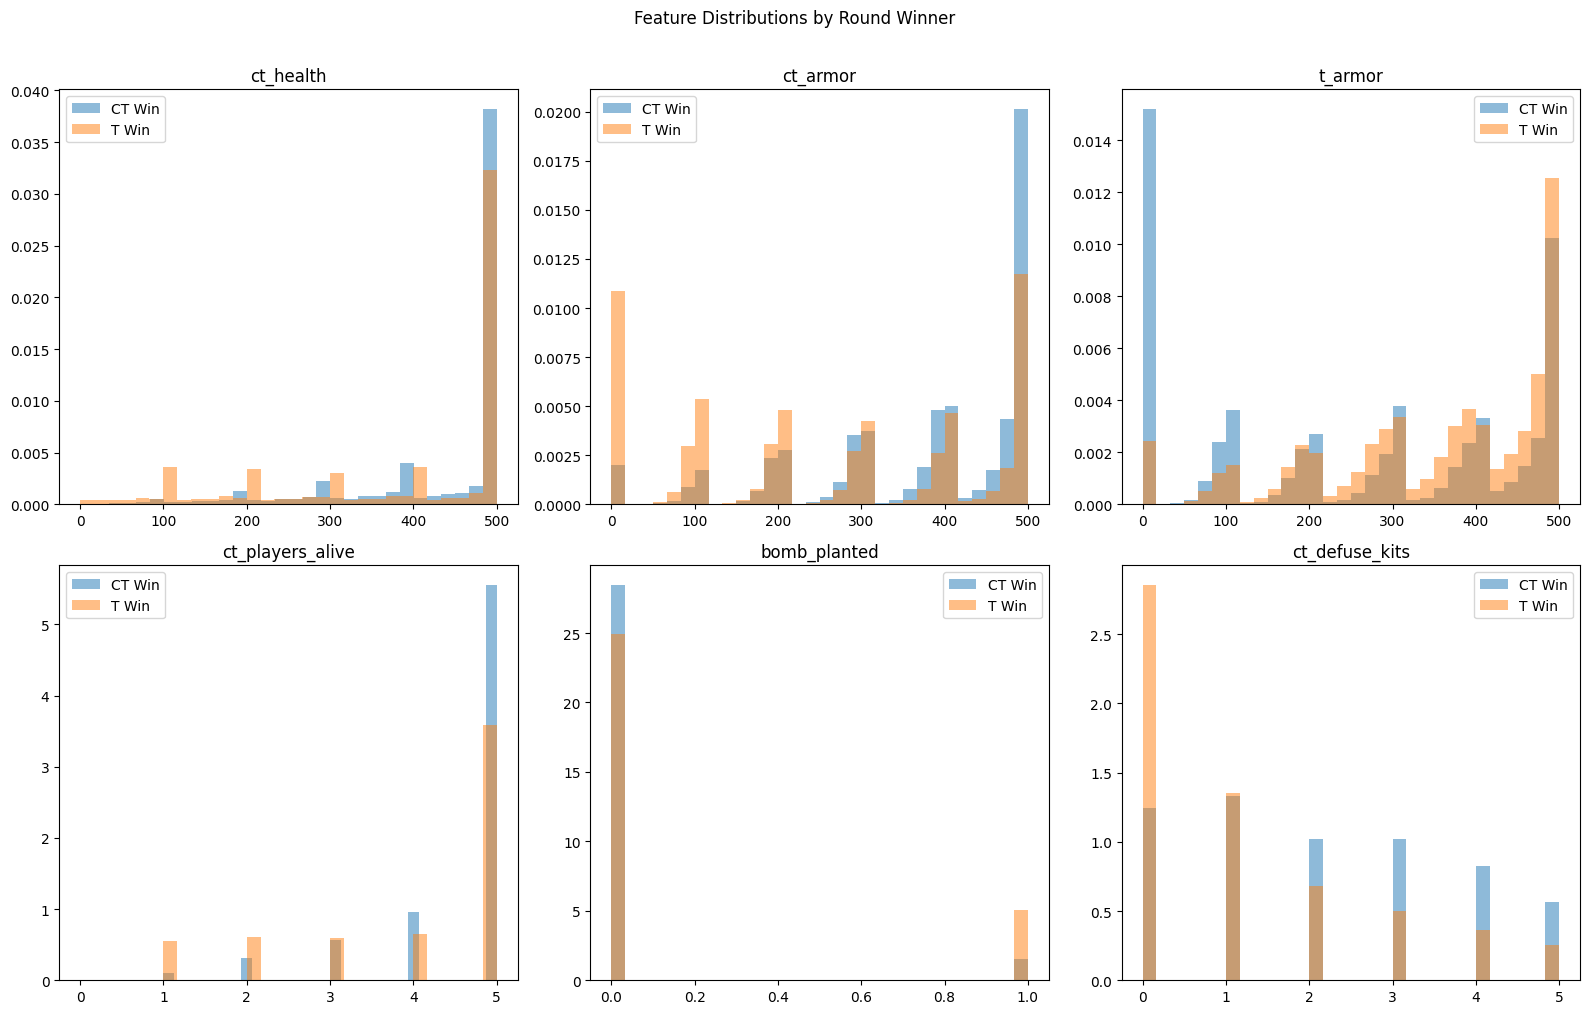

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_features = ["ct_health", "ct_armor", "t_armor", "ct_players_alive", "bomb_planted", "ct_defuse_kits"]

for ax, feat in zip(axes.flat, key_features):
    for label, group in df.groupby("t_win"):
        name = "CT Win" if label == 0 else "T Win"
        data = group[feat].astype(float)
        ax.hist(data, bins=30, alpha=0.5, label=name, density=True)
    ax.set_title(feat)
    ax.legend()

plt.suptitle("Feature Distributions by Round Winner", y=1.01)
plt.tight_layout()
plt.show()

## All Weapons & Maps

In [35]:
# Extract weapon names
weapon_cols = [c for c in df.columns if "_weapon_" in c]
weapons = sorted(set(c.split("_weapon_")[1] for c in weapon_cols))

print(f"Weapons ({len(weapons)}):")
for w in weapons:
    print(f"  - {w}")

print(f"\nMaps ({df['map'].nunique()}):")
for m in sorted(df["map"].unique()):
    print(f"  - {m}")

Weapons (34):
  - ak47
  - aug
  - awp
  - bizon
  - cz75auto
  - deagle
  - elite
  - famas
  - fiveseven
  - g3sg1
  - galilar
  - glock
  - m249
  - m4a1s
  - m4a4
  - mac10
  - mag7
  - mp5sd
  - mp7
  - mp9
  - negev
  - nova
  - p2000
  - p250
  - p90
  - r8revolver
  - sawedoff
  - scar20
  - sg553
  - ssg08
  - tec9
  - ump45
  - usps
  - xm1014

Maps (8):
  - de_cache
  - de_dust2
  - de_inferno
  - de_mirage
  - de_nuke
  - de_overpass
  - de_train
  - de_vertigo


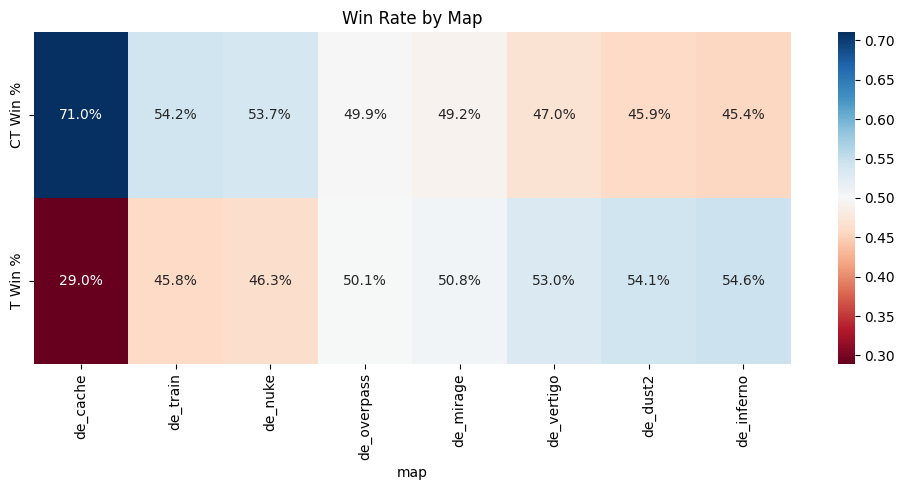

In [34]:
# Win rate by map
map_stats = df.groupby("map")["t_win"].agg(["mean", "count"]).rename(columns={"mean": "t_win_rate", "count": "rounds"})
map_stats["ct_win_rate"] = 1 - map_stats["t_win_rate"]
map_stats = map_stats.sort_values("ct_win_rate", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    map_stats[["ct_win_rate", "t_win_rate"]].T,
    annot=True, fmt=".1%", cmap="RdBu", center=0.5, ax=ax,
    xticklabels=map_stats.index,
    yticklabels=["CT Win %", "T Win %"],
)
ax.set_title("Win Rate by Map")
plt.tight_layout()
plt.show()

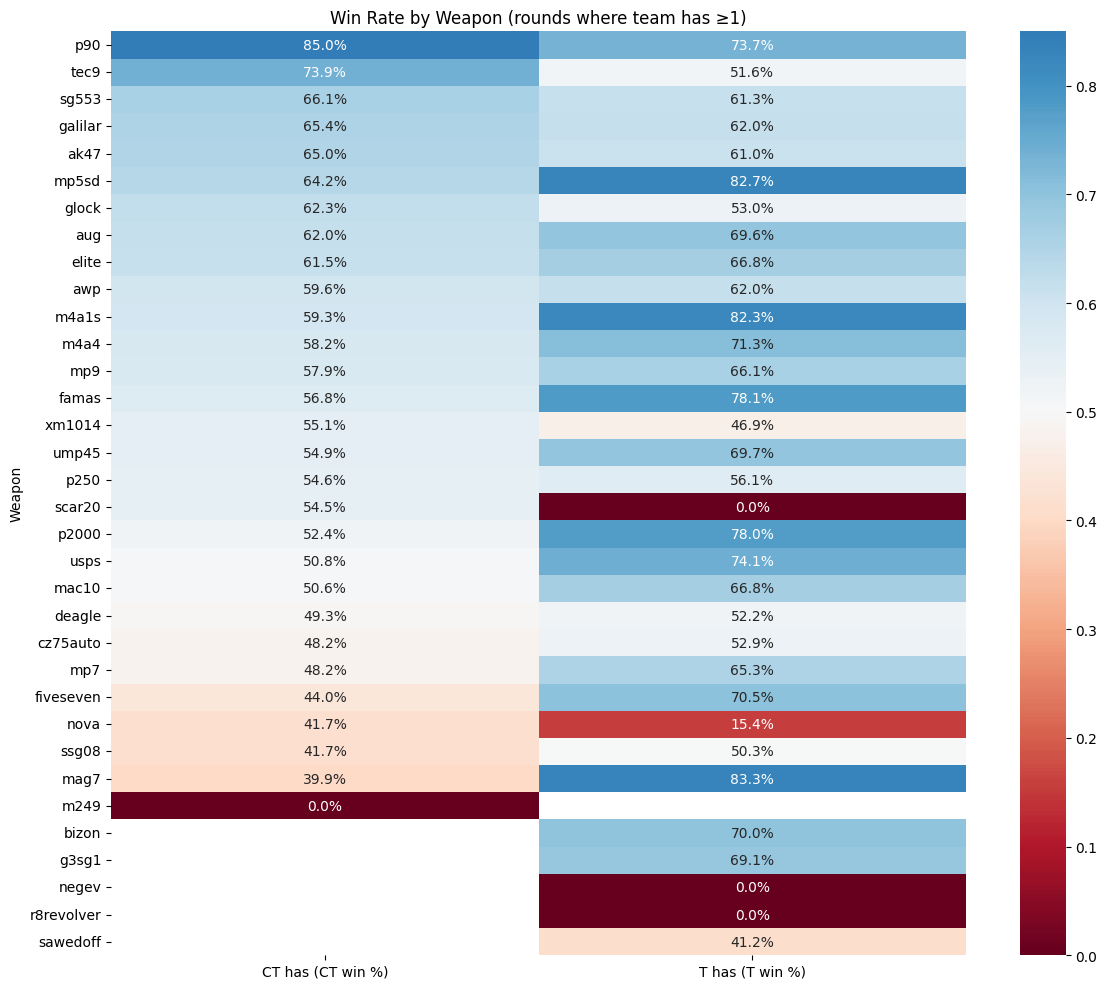

In [33]:
# CT win rate when a team has at least 1 of each weapon
weapon_winrates = {}

for weapon in weapons:
    ct_col = f"ct_weapon_{weapon}"
    t_col = f"t_weapon_{weapon}"

    # Rounds where CT has this weapon → CT win rate
    ct_has = df[df[ct_col] > 0]
    if len(ct_has) > 0:
        weapon_winrates.setdefault(weapon, {})["CT has (CT win %)"] = 1 - ct_has["t_win"].mean()

    # Rounds where T has this weapon → T win rate
    t_has = df[df[t_col] > 0]
    if len(t_has) > 0:
        weapon_winrates.setdefault(weapon, {})["T has (T win %)"] = t_has["t_win"].mean()

wr_df = pd.DataFrame(weapon_winrates).T.sort_values("CT has (CT win %)", ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    wr_df,
    annot=True, fmt=".1%", cmap="RdBu", center=0.5, ax=ax,
)
ax.set_title("Win Rate by Weapon (rounds where team has ≥1)")
ax.set_ylabel("Weapon")
plt.tight_layout()
plt.show()

## Save Features for Later

In [36]:
import json

config = {
    "selected_features": selected,
    "target": "t_win",
    "dataset_shape": list(df.shape),
}

(DATA_DIR / "config.json").write_text(json.dumps(config, indent=2))
print(f"Saved {len(selected)} selected features to data/config.json")

Saved 20 selected features to data/config.json
